In [1]:
# Cell 1 — Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [5]:
# Cell 2 — Load the data
df = pd.read_csv('OnlineNewsPopularityReduced.csv')
df.columns = df.columns.str.strip()   # removes hidden spaces from column names

print(f"Rows:    {df.shape[0]}")       # should print ~58,645
print(f"Columns: {df.shape[1]}")       # should print 61
print(df.head(3))                      # preview first 3 rows

Rows:    4954
Columns: 61
                                                 url  timedelta  \
0  http://mashable.com/2014/09/28/jobs-tech-workers/        101   
1  http://mashable.com/2014/09/28/obama-says-u-s-...        101   
2  http://mashable.com/2014/09/28/once-upon-a-tim...        101   

   n_tokens_title  n_tokens_content  n_unique_tokens  n_non_stop_words  \
0              12               332         0.528481               1.0   
1              10               393         0.518817               1.0   
2              13              1643         0.388854               1.0   

   n_non_stop_unique_tokens  num_hrefs  num_self_hrefs  num_imgs  ...  \
0                  0.645833          6               3         1  ...   
1                  0.596899         14               1         1  ...   
2                  0.546967         29               4         7  ...   

   min_positive_polarity  max_positive_polarity  avg_negative_polarity  \
0               0.100000                 

In [6]:
# Cell 3 — Create the viral label
THRESHOLD = 1400   # articles with more than 1400 shares = viral

df['viral'] = (df['shares'] > THRESHOLD).astype(int)

# Check the class balance
print(df['viral'].value_counts())
print()
print(df['viral'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

viral
0    2597
1    2357
Name: count, dtype: int64

viral
0    52.4%
1    47.6%
Name: proportion, dtype: object


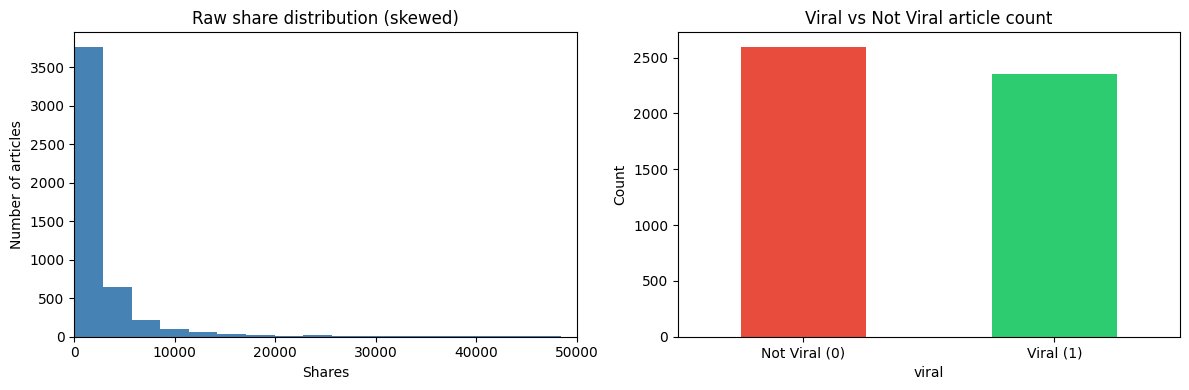

In [7]:
# Cell 4 — Visualize the share distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw share counts (very skewed)
axes[0].hist(df['shares'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Raw share distribution (skewed)')
axes[0].set_xlabel('Shares')
axes[0].set_ylabel('Number of articles')
axes[0].set_xlim(0, 50000)   # zoom in, ignores extreme outliers

# Right: viral vs not viral count
df['viral'].value_counts().plot(kind='bar', ax=axes[1],
    color=['#e74c3c', '#2ecc71'], edgecolor='none')
axes[1].set_title('Viral vs Not Viral article count')
axes[1].set_xticklabels(['Not Viral (0)', 'Viral (1)'], rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('phase1_plots.png', dpi=150)
plt.show()

In [8]:
# Cell 5 — Data quality check
print("=== Missing Values ===")
print(df.isnull().sum().sum(), "total missing values")
print()
print("=== Shape ===")
print(f"{df.shape[0]} articles, {df.shape[1]} columns")
print()
print("=== Shares Statistics ===")
print(df['shares'].describe().round(0))

=== Missing Values ===
0 total missing values

=== Shape ===
4954 articles, 62 columns

=== Shares Statistics ===
count      4954.0
mean       3341.0
std        9183.0
min           5.0
25%         945.0
50%        1400.0
75%        2700.0
max      284700.0
Name: shares, dtype: float64


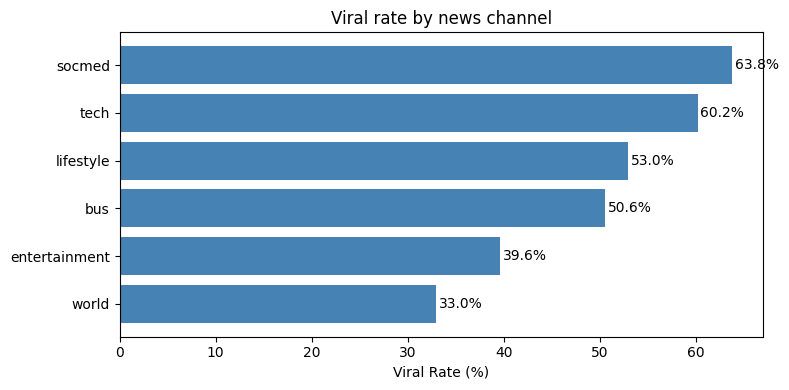

In [9]:
# Cell 6 — Viral rate by news channel
channel_cols = [c for c in df.columns if 'data_channel_is_' in c]

viral_by_channel = {}
for col in channel_cols:
    name = col.replace('data_channel_is_', '')
    subset = df[df[col] == 1]
    viral_rate = subset['viral'].mean() * 100
    viral_by_channel[name] = round(viral_rate, 1)

channel_df = pd.Series(viral_by_channel).sort_values()

plt.figure(figsize=(8, 4))
bars = plt.barh(channel_df.index, channel_df.values, color='steelblue', edgecolor='none')
plt.xlabel('Viral Rate (%)')
plt.title('Viral rate by news channel')
for bar, val in zip(bars, channel_df.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('viral_by_channel.png', dpi=150)
plt.show()

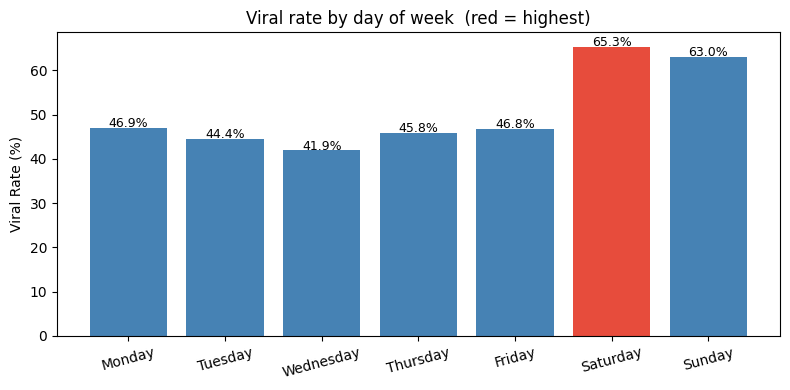

In [10]:
# Cell 7 — Viral rate by day of week
day_cols = {
    'weekday_is_monday':    'Monday',
    'weekday_is_tuesday':   'Tuesday',
    'weekday_is_wednesday': 'Wednesday',
    'weekday_is_thursday':  'Thursday',
    'weekday_is_friday':    'Friday',
    'weekday_is_saturday':  'Saturday',
    'weekday_is_sunday':    'Sunday'
}

viral_by_day = {}
for col, name in day_cols.items():
    subset = df[df[col] == 1]
    viral_by_day[name] = round(subset['viral'].mean() * 100, 1)

day_df = pd.Series(viral_by_day)

plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if v == day_df.max() else 'steelblue' for v in day_df.values]
bars = plt.bar(day_df.index, day_df.values, color=colors, edgecolor='none')
plt.ylabel('Viral Rate (%)')
plt.title('Viral rate by day of week  (red = highest)')
plt.xticks(rotation=15)
for bar, val in zip(bars, day_df.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.2,
             f'{val}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('viral_by_day.png', dpi=150)
plt.show()

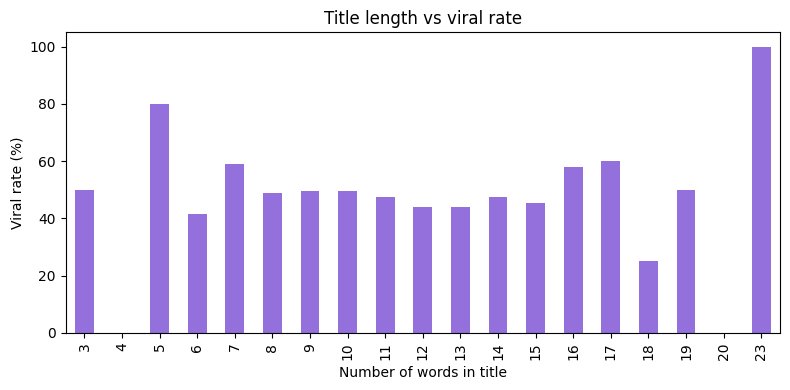

In [11]:
# Cell 8 — Does title word count affect virality?
plt.figure(figsize=(8, 4))
df.groupby('n_tokens_title')['viral'].mean().mul(100).plot(
    kind='bar', color='mediumpurple', edgecolor='none')
plt.xlabel('Number of words in title')
plt.ylabel('Viral rate (%)')
plt.title('Title length vs viral rate')
plt.tight_layout()
plt.savefig('title_length_viral.png', dpi=150)
plt.show()

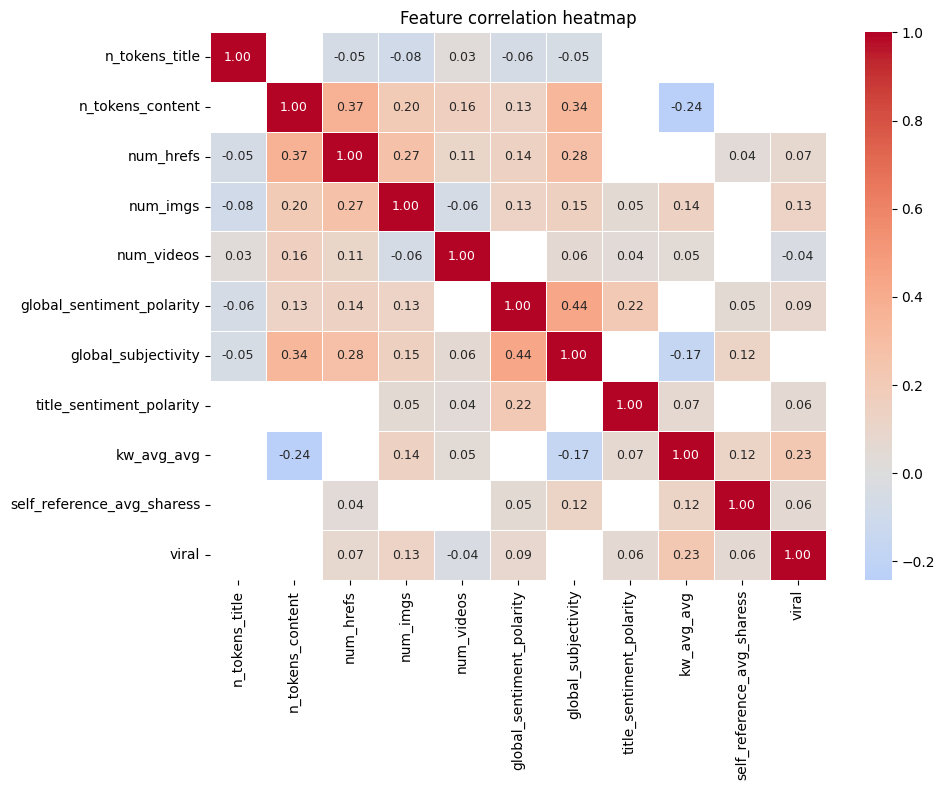

In [12]:
# Cell 9 — Correlation heatmap of top features vs viral
top_features = [
    'n_tokens_title', 'n_tokens_content', 'num_hrefs',
    'num_imgs', 'num_videos', 'global_sentiment_polarity',
    'global_subjectivity', 'title_sentiment_polarity',
    'kw_avg_avg', 'self_reference_avg_sharess', 'viral'
]

plt.figure(figsize=(10, 8))
corr = df[top_features].corr()
mask = corr.abs() < 0.03   # hide very weak correlations
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [13]:
# Cell 10 — Text features
# These columns already exist in the dataset, we just make sure they're clean

text_features = [
    'n_tokens_title',       # number of words in the title
    'n_tokens_content',     # number of words in the article
    'n_unique_tokens',      # ratio of unique words (vocabulary richness)
    'num_hrefs',            # number of links in the article
    'num_self_hrefs',       # links pointing to other Mashable articles
    'num_imgs',             # number of images
    'num_videos',           # number of videos
    'average_token_length', # average word length
]

print("=== Text Feature Stats ===")
print(df[text_features].describe().round(2))

=== Text Feature Stats ===
       n_tokens_title  n_tokens_content  n_unique_tokens  num_hrefs  \
count         4954.00           4954.00          4954.00    4954.00   
mean            11.20            550.41             0.48      10.36   
std              2.18            457.90             0.18      12.53   
min              3.00              0.00             0.00       0.00   
25%             10.00            256.00             0.45       3.00   
50%             11.00            436.00             0.52       7.00   
75%             13.00            753.75             0.58      13.00   
max             23.00           6159.00             1.00     304.00   

       num_self_hrefs  num_imgs  num_videos  average_token_length  
count         4954.00   4954.00     4954.00               4954.00  
mean             2.68      3.57        1.17                  4.24  
std              3.40      5.98        3.77                  1.43  
min              0.00      0.00        0.00                  

In [14]:
# Cell 11 — Sentiment features
# These measure the emotional tone of the article

sentiment_features = [
    'global_subjectivity',          # how opinionated (0=objective, 1=subjective)
    'global_sentiment_polarity',    # positive vs negative (-1 to +1)
    'global_rate_positive_words',   # % of positive words
    'global_rate_negative_words',   # % of negative words
    'title_subjectivity',           # subjectivity of the headline
    'title_sentiment_polarity',     # sentiment of the headline
    'abs_title_sentiment_polarity', # absolute sentiment strength of headline
]

# Add a new engineered feature: strong sentiment flag
df['strong_sentiment'] = (df['global_sentiment_polarity'].abs() > 0.2).astype(int)
df['positive_title']   = (df['title_sentiment_polarity'] > 0.1).astype(int)

print("=== Articles with strong sentiment ===")
print(df['strong_sentiment'].value_counts())
print()
print("=== Strong sentiment vs viral rate ===")
print(df.groupby('strong_sentiment')['viral'].mean().mul(100).round(1).astype(str) + '%')

=== Articles with strong sentiment ===
strong_sentiment
0    4292
1     662
Name: count, dtype: int64

=== Strong sentiment vs viral rate ===
strong_sentiment
0    46.6%
1    53.9%
Name: viral, dtype: object


In [15]:
# Cell 12 — Metadata features
# Publication timing, topic category, keyword popularity

metadata_features = [
    # Day of week (already one-hot encoded)
    'weekday_is_monday', 'weekday_is_tuesday', 'weekday_is_wednesday',
    'weekday_is_thursday', 'weekday_is_friday',
    'weekday_is_saturday', 'weekday_is_sunday', 'is_weekend',

    # Topic channel (already one-hot encoded)
    'data_channel_is_lifestyle', 'data_channel_is_entertainment',
    'data_channel_is_bus',       'data_channel_is_socmed',
    'data_channel_is_tech',      'data_channel_is_world',

    # Keyword features
    'kw_min_avg',   # avg shares of worst keyword
    'kw_max_avg',   # avg shares of best keyword
    'kw_avg_avg',   # avg shares of all keywords (very predictive!)

    # Self-reference features
    'self_reference_min_shares',  # min shares of referenced articles
    'self_reference_avg_sharess', # avg shares of referenced articles
]

print("=== Metadata feature sample ===")
print(df[metadata_features].head(3))

=== Metadata feature sample ===
   weekday_is_monday  weekday_is_tuesday  weekday_is_wednesday  \
0                  1                   0                     0   
1                  1                   0                     0   
2                  1                   0                     0   

   weekday_is_thursday  weekday_is_friday  weekday_is_saturday  \
0                    0                  0                    0   
1                    0                  0                    0   
2                    0                  0                    0   

   weekday_is_sunday  is_weekend  data_channel_is_lifestyle  \
0                  0           0                          0   
1                  0           0                          0   
2                  0           0                          0   

   data_channel_is_entertainment  data_channel_is_bus  data_channel_is_socmed  \
0                              0                    0                       0   
1                      

In [16]:
# Cell 13 — Build final feature matrix X and target y

# Combine all feature groups
all_features = text_features + sentiment_features + metadata_features + [
    'strong_sentiment',   # our new engineered features
    'positive_title',
    'LDA_00', 'LDA_01', 'LDA_02', 'LDA_03', 'LDA_04',  # topic distributions
]

# Drop any duplicates in feature list
all_features = list(dict.fromkeys(all_features))

X = df[all_features].copy()
y = df['viral'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print()
print(f"Viral articles:     {y.sum()} ({y.mean()*100:.1f}%)")
print(f"Non-viral articles: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print()
print("=== Any missing values in X? ===")
print(X.isnull().sum().sum(), "missing values")

Feature matrix shape: (4954, 41)
Target variable shape: (4954,)

Viral articles:     2357 (47.6%)
Non-viral articles: 2597 (52.4%)

=== Any missing values in X? ===
0 missing values


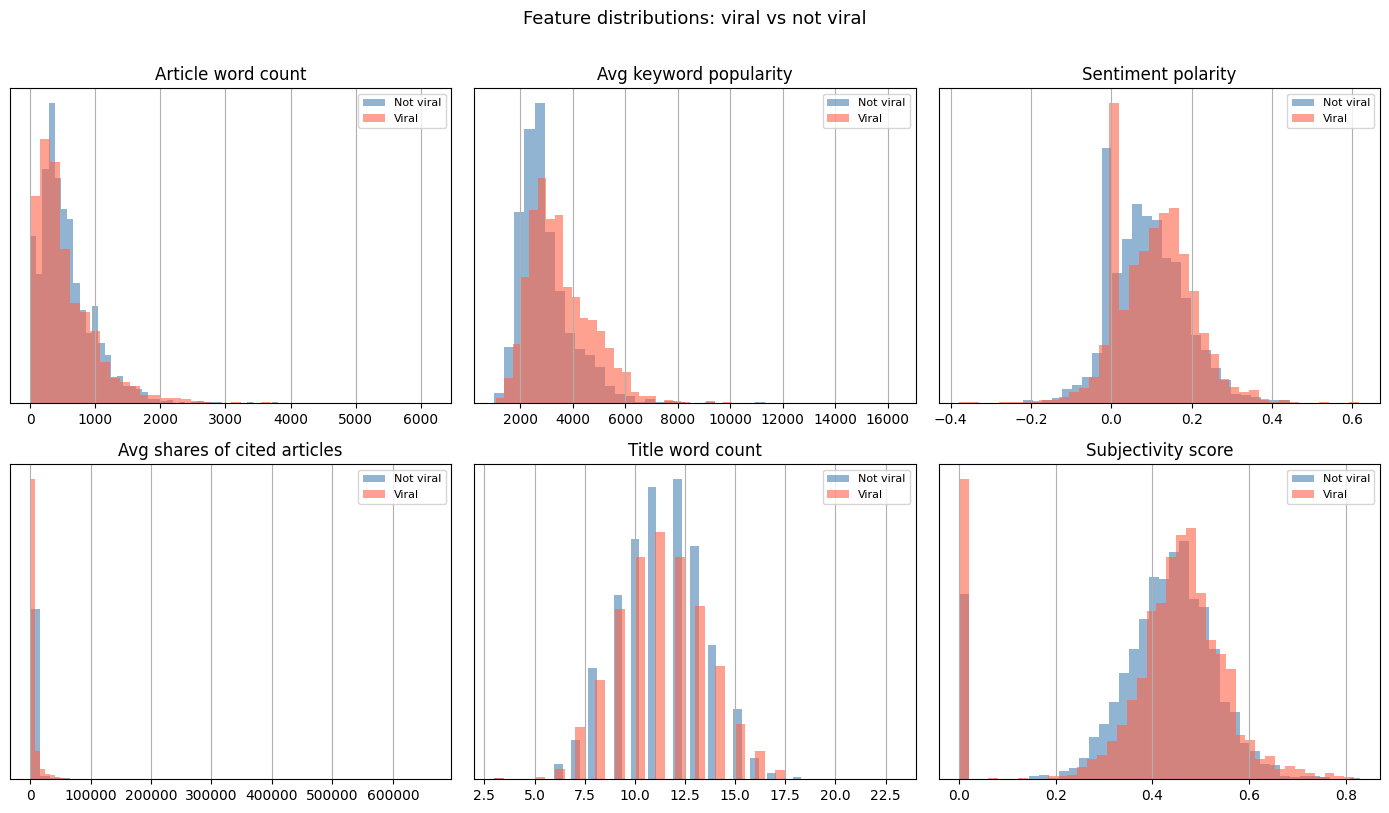

In [17]:
# Cell 14 — Plot key feature distributions split by viral vs not viral
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features_to_plot = [
    ('n_tokens_content',           'Article word count'),
    ('kw_avg_avg',                 'Avg keyword popularity'),
    ('global_sentiment_polarity',  'Sentiment polarity'),
    ('self_reference_avg_sharess', 'Avg shares of cited articles'),
    ('n_tokens_title',             'Title word count'),
    ('global_subjectivity',        'Subjectivity score'),
]

for ax, (feat, label) in zip(axes, features_to_plot):
    df[df['viral']==0][feat].hist(ax=ax, bins=40, alpha=0.6,
                                   color='steelblue', label='Not viral', density=True)
    df[df['viral']==1][feat].hist(ax=ax, bins=40, alpha=0.6,
                                   color='tomato', label='Viral', density=True)
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.set_yticks([])

plt.suptitle('Feature distributions: viral vs not viral', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()

In [18]:
# Cell 15 — Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # same split every time you run
    stratify=y          # keep viral ratio equal in both splits
)

print(f"Training set:   {X_train.shape[0]} articles")
print(f"Test set:       {X_test.shape[0]} articles")
print()
print(f"Viral in train: {y_train.mean()*100:.1f}%")
print(f"Viral in test:  {y_test.mean()*100:.1f}%")

Training set:   3963 articles
Test set:       991 articles

Viral in train: 47.6%
Viral in test:  47.5%


In [19]:
# Cell 16 — Calculate scale_pos_weight for XGBoost
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Non-viral articles: {neg}")
print(f"Viral articles:     {pos}")
print(f"scale_pos_weight:   {scale_pos_weight:.3f}")

Non-viral articles: 2077
Viral articles:     1886
scale_pos_weight:   1.101


In [20]:
# Cell 17 — Train baseline XGBoost model
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

print("Training baseline model... (takes ~30 seconds)")

baseline_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0
)

baseline_model.fit(X_train, y_train)

y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print()
if baseline_auc >= 0.70:
    print("Solid result! Now let's tune it further.")
elif baseline_auc >= 0.65:
    print("Decent start. Tuning will improve this significantly.")
else:
    print("Low score — check your feature matrix X is built correctly.")

Training baseline model... (takes ~30 seconds)
Baseline ROC-AUC: 0.6922

Decent start. Tuning will improve this significantly.


In [22]:
# Cell 18 — Train tuned XGBoost model with early stopping
print("Training tuned model... (takes ~1-2 minutes)")

tuned_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0,
    early_stopping_rounds=30
)

tuned_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred_proba_tuned = tuned_model.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, y_pred_proba_tuned)

print(f"Baseline ROC-AUC: {baseline_auc:.4f}")
print(f"Tuned ROC-AUC:    {tuned_auc:.4f}")
print(f"Improvement:      +{(tuned_auc - baseline_auc):.4f}")

Training tuned model... (takes ~1-2 minutes)
[0]	validation_0-auc:0.68800
[50]	validation_0-auc:0.72306
[65]	validation_0-auc:0.72304
Baseline ROC-AUC: 0.6922
Tuned ROC-AUC:    0.7251
Improvement:      +0.0330


In [23]:
# Cell 19 — Save model to disk
import joblib

joblib.dump(tuned_model, 'model.pkl')
joblib.dump(list(X.columns), 'feature_cols.pkl')

print("Model saved as model.pkl")
print("Feature list saved as feature_cols.pkl")
print()
print(f"Best iteration: {tuned_model.best_iteration}")
print(f"Final ROC-AUC:  {tuned_auc:.4f}")

Model saved as model.pkl
Feature list saved as feature_cols.pkl

Best iteration: 35
Final ROC-AUC:  0.7251


In [24]:
# Cell 20 — Classification report
from sklearn.metrics import classification_report, roc_auc_score

y_pred = tuned_model.predict(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Not Viral', 'Viral']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tuned):.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

   Not Viral       0.69      0.66      0.67       520
       Viral       0.64      0.68      0.66       471

    accuracy                           0.67       991
   macro avg       0.67      0.67      0.67       991
weighted avg       0.67      0.67      0.67       991

ROC-AUC Score: 0.7251


C:\Users\User\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


<Figure size 700x600 with 0 Axes>

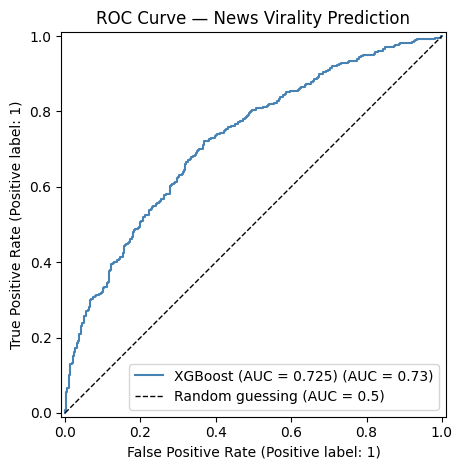

In [25]:
# Cell 21 — ROC curve
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba_tuned,
    name=f"XGBoost (AUC = {tuned_auc:.3f})",
    color="steelblue"
)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guessing (AUC = 0.5)')
plt.title('ROC Curve — News Virality Prediction')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

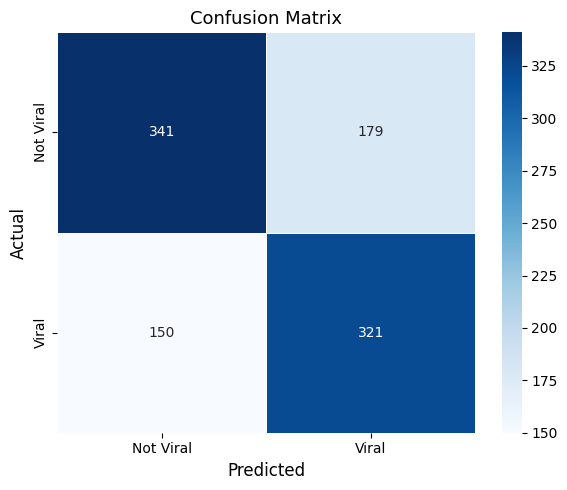

Correctly predicted NOT viral: 341
Correctly predicted viral:     321
Viral articles missed:         150
False alarms (not viral, predicted viral): 179


In [26]:
# Cell 22 — Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Viral', 'Viral'],
            yticklabels=['Not Viral', 'Viral'],
            linewidths=0.5)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Print readable breakdown
tn, fp, fn, tp = cm.ravel()
print(f"Correctly predicted NOT viral: {tn}")
print(f"Correctly predicted viral:     {tp}")
print(f"Viral articles missed:         {fn}")
print(f"False alarms (not viral, predicted viral): {fp}")

Calculating SHAP values... (takes ~30 seconds)


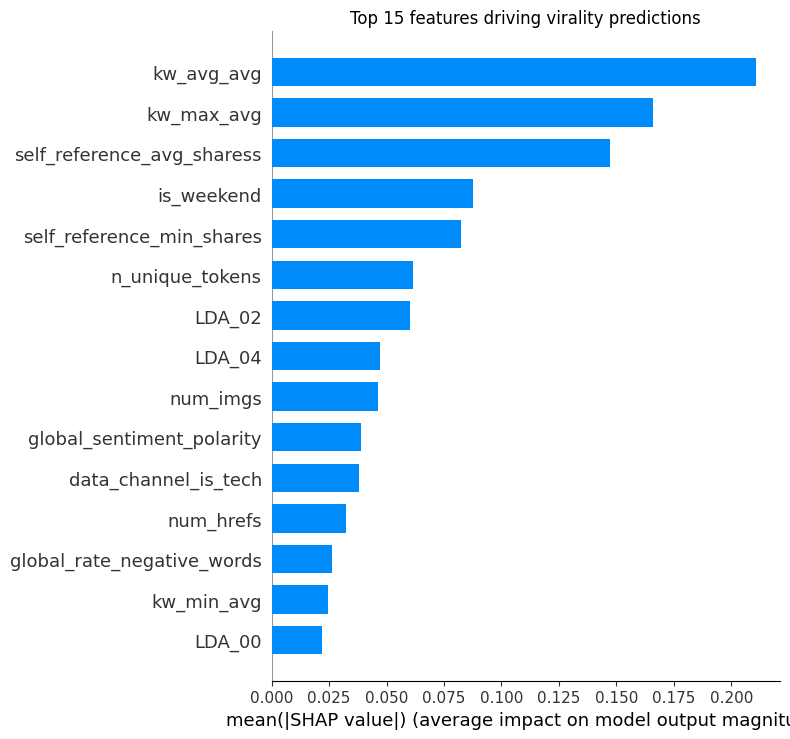

In [28]:
# Cell 23 — SHAP feature importance
import shap

print("Calculating SHAP values... (takes ~30 seconds)")

explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test.iloc[:1000])

# Bar plot — overall importance
shap.summary_plot(
    shap_values,
    X_test.iloc[:1000],
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Top 15 features driving virality predictions')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150)
plt.show()

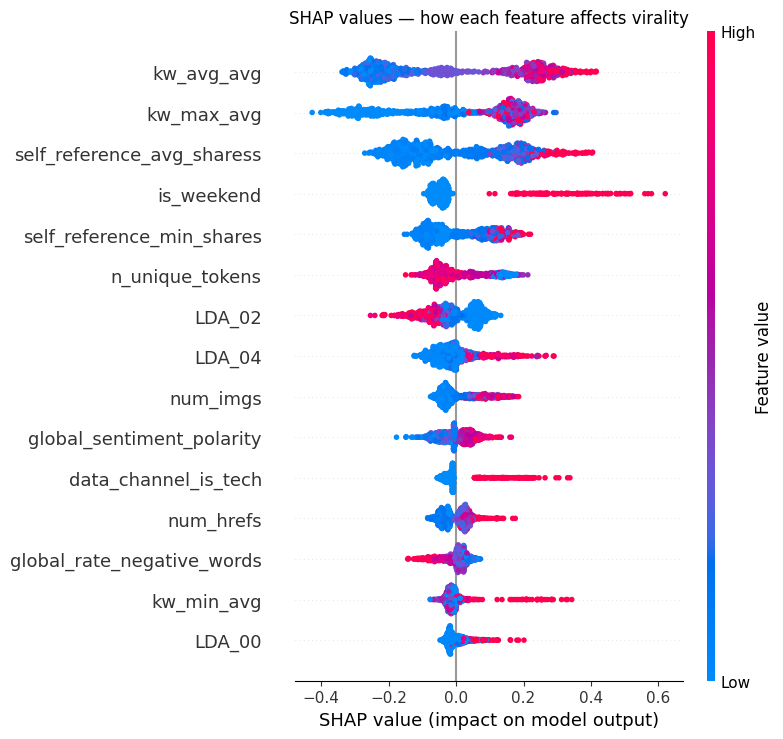

In [29]:
# Cell 24 — SHAP dot plot (shows direction of each feature's effect)
shap.summary_plot(
    shap_values,
    X_test.iloc[:1000],
    max_display=15,
    show=False
)
plt.title('SHAP values — how each feature affects virality')
plt.tight_layout()
plt.savefig('shap_dot_plot.png', dpi=150)
plt.show()

In [32]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score
)

y_pred = tuned_model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_pred_proba_tuned)
f1        = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)

print("=" * 40)
print("       MODEL PERFORMANCE REPORT")
print("=" * 40)
print(f"Accuracy:   {accuracy*100:.2f}%")
print(f"ROC-AUC:    {auc*100:.2f}%")
print(f"F1 Score:   {f1*100:.2f}%")
print(f"Precision:  {precision*100:.2f}%")
print(f"Recall:     {recall*100:.2f}%")
print("=" * 40)

       MODEL PERFORMANCE REPORT
Accuracy:   66.80%
ROC-AUC:    72.51%
F1 Score:   66.12%
Precision:  64.20%
Recall:     68.15%
